In [1]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn lifelines

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 10.1 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 62.6 MB/s eta 0:00:00m eta 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 16.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ec9c50fc85ef122cc97b0fa3f17532172d12c0b9fc6c95ce5533d53c3c5361a5
  Stored in directory: /Users/monicachaganti/Library/Caches/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.3
    Uninstalling pandas-3.0.3:
      Successfully uninstalled pandas-3.0.3
ERROR: pip's dependency resolver does not curren

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
PROJECT_DIR = Path(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/brca_metabric"
)

# Clinical patient data
patient_file = PROJECT_DIR / "data_clinical_patient.txt"

# Clinical sample data
sample_file = PROJECT_DIR / "data_clinical_sample.txt"

print("Patient file exists:", patient_file.exists())
print("Sample file exists:", sample_file.exists())

Patient file exists: True
Sample file exists: True


In [6]:

patient_df = pd.read_csv(
    patient_file,
    sep="\t",
    comment="#",
    low_memory=False
)

print("Patient dataset loaded successfully!")

print("\nDataset dimensions:")
print(patient_df.shape)

print("\nFirst five patient records:")
display(patient_df.head())

Patient dataset loaded successfully!

Dataset dimensions:
(2509, 24)

First five patient records:


,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,SEX,INTCLUST,AGE_AT_DIAGNOSIS,OS_MONTHS,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS
0,MB-0000,10.0,6.044,NaN,NO,1.0,Positve,NEUTRAL,YES,Post,Female,4ER+,75.65,140.500000,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.500000,0:Not Recurred
1,MB-0002,0.0,4.020,High,NO,1.0,Positve,NEUTRAL,YES,Pre,Female,4ER+,43.19,84.633333,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.633333,0:Not Recurred
2,MB-0005,1.0,4.030,High,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,3,48.87,163.700000,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.300000,1:Recurred
3,MB-0006,3.0,4.050,Moderate,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,9,47.68,164.933333,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333,0:Not Recurred
4,MB-0008,8.0,6.080,High,YES,1.0,Positve,NEUTRAL,YES,Post,Female,9,76.97,41.366667,1:DECEASED,LumB,ER+/HER2- High Prolif,Died of Disease,Right,YES,Mixed,MASTECTOMY,18.800000,1:Recurred


In [8]:

sample_df = pd.read_csv(
    sample_file,
    sep="\t",
    comment="#",
    low_memory=False
)

print("Sample dataset loaded successfully!")

print("\nDataset dimensions:")
print(sample_df.shape)

print("\nFirst five sample records:")
display(sample_df.head())

Sample dataset loaded successfully!

Dataset dimensions:
(2509, 13)

First five sample records:


,PATIENT_ID,SAMPLE_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,ER_STATUS,HER2_STATUS,GRADE,ONCOTREE_CODE,PR_STATUS,SAMPLE_TYPE,TUMOR_SIZE,TUMOR_STAGE,TMB_NONSYNONYMOUS
0,MB-0000,MB-0000,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Negative,Primary,22.0,2.0,0.000000
1,MB-0002,MB-0002,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Positive,Primary,10.0,1.0,2.615035
2,MB-0005,MB-0005,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,2.0,IDC,Positive,Primary,15.0,2.0,2.615035
3,MB-0006,MB-0006,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,2.0,MDLC,Positive,Primary,25.0,2.0,1.307518
4,MB-0008,MB-0008,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,3.0,MDLC,Positive,Primary,40.0,2.0,2.615035


In [10]:

print("=" * 60)
print("PATIENT DATASET")
print("=" * 60)

print("Number of rows:", patient_df.shape[0])
print("Number of columns:", patient_df.shape[1])

print("\nPatient dataset columns:")
print(patient_df.columns.tolist())

print("\n" + "=" * 60)
print("SAMPLE DATASET")
print("=" * 60)

print("Number of rows:", sample_df.shape[0])
print("Number of columns:", sample_df.shape[1])

print("\nSample dataset columns:")
print(sample_df.columns.tolist())

PATIENT DATASET
Number of rows: 2509
Number of columns: 24

Patient dataset columns:
['PATIENT_ID', 'LYMPH_NODES_EXAMINED_POSITIVE', 'NPI', 'CELLULARITY', 'CHEMOTHERAPY', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HORMONE_THERAPY', 'INFERRED_MENOPAUSAL_STATE', 'SEX', 'INTCLUST', 'AGE_AT_DIAGNOSIS', 'OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE', 'THREEGENE', 'VITAL_STATUS', 'LATERALITY', 'RADIO_THERAPY', 'HISTOLOGICAL_SUBTYPE', 'BREAST_SURGERY', 'RFS_MONTHS', 'RFS_STATUS']

SAMPLE DATASET
Number of rows: 2509
Number of columns: 13

Sample dataset columns:
['PATIENT_ID', 'SAMPLE_ID', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED', 'ER_STATUS', 'HER2_STATUS', 'GRADE', 'ONCOTREE_CODE', 'PR_STATUS', 'SAMPLE_TYPE', 'TUMOR_SIZE', 'TUMOR_STAGE', 'TMB_NONSYNONYMOUS']


In [12]:

print("PATIENT DATA INFORMATION")
print("-" * 60)

patient_df.info()

print("\nSAMPLE DATA INFORMATION")
print("-" * 60)

sample_df.info()

PATIENT DATA INFORMATION
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PATIENT_ID                     2509 non-null   object 
 1   LYMPH_NODES_EXAMINED_POSITIVE  2243 non-null   float64
 2   NPI                            2287 non-null   float64
 3   CELLULARITY                    1917 non-null   object 
 4   CHEMOTHERAPY                   1980 non-null   object 
 5   COHORT                         2498 non-null   float64
 6   ER_IHC                         2426 non-null   object 
 7   HER2_SNP6                      1980 non-null   object 
 8   HORMONE_THERAPY                1980 non-null   object 
 9   INFERRED_MENOPAUSAL_STATE      1980 non-null   object 
 10  SEX                            2509 non-null   object 
 11  INTCLUST              

In [14]:


survival_columns = [
    col for col in patient_df.columns
    if any(
        keyword in col.upper()
        for keyword in [
            "SURVIVAL",
            "OS_",
            "DFS_",
            "RFS_",
            "PFS_"
        ]
    )
]

print("Survival-related columns:")
print(survival_columns)

print("\nFirst 10 records:")

if survival_columns:
    display(
        patient_df[survival_columns].head(10)
    )
else:
    print("No survival-related columns found.")

Survival-related columns:
['OS_MONTHS', 'OS_STATUS', 'RFS_MONTHS', 'RFS_STATUS']

First 10 records:


,OS_MONTHS,OS_STATUS,RFS_MONTHS,RFS_STATUS
0,140.500000,0:LIVING,140.500000,0:Not Recurred
1,84.633333,0:LIVING,84.633333,0:Not Recurred
2,163.700000,1:DECEASED,153.300000,1:Recurred
3,164.933333,0:LIVING,164.933333,0:Not Recurred
4,41.366667,1:DECEASED,18.800000,1:Recurred
5,7.800000,1:DECEASED,2.933333,1:Recurred
6,164.333333,0:LIVING,164.333333,0:Not Recurred
7,22.400000,1:DECEASED,11.900000,1:Recurred
8,99.533333,1:DECEASED,99.533333,0:Not Recurred
9,NaN,NaN,128.000000,1:Recurred


In [16]:


required_columns = ["OS_MONTHS", "OS_STATUS"]

if all(
    col in patient_df.columns
    for col in required_columns
):

    print("Overall survival variables found!")

    display(
        patient_df[
            ["OS_MONTHS", "OS_STATUS"]
        ].head(15)
    )

    print("\nSurvival status distribution:")

    print(
        patient_df["OS_STATUS"].value_counts(
            dropna=False
        )
    )

else:
    print("Expected survival columns not found.")

    print(
        "Available survival columns:",
        survival_columns
    )

Overall survival variables found!


,OS_MONTHS,OS_STATUS
0,140.500000,0:LIVING
1,84.633333,0:LIVING
2,163.700000,1:DECEASED
3,164.933333,0:LIVING
4,41.366667,1:DECEASED
5,7.800000,1:DECEASED
6,164.333333,0:LIVING
7,22.400000,1:DECEASED
8,99.533333,1:DECEASED
9,NaN,NaN



Survival status distribution:
OS_STATUS
1:DECEASED    1144
0:LIVING       837
NaN            528
Name: count, dtype: int64


In [18]:


missing_count = patient_df.isnull().sum()

missing_percentage = (
    patient_df.isnull().mean() * 100
)


missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})


missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

print("Missing values in patient dataset:")

display(missing_summary)

Missing values in patient dataset:


,Missing_Count,Missing_Percentage
THREEGENE,745,29.693105
LATERALITY,639,25.468314
CELLULARITY,592,23.595058
BREAST_SURGERY,554,22.080510
INFERRED_MENOPAUSAL_STATE,529,21.084097
VITAL_STATUS,529,21.084097
CLAUDIN_SUBTYPE,529,21.084097
INTCLUST,529,21.084097
RADIO_THERAPY,529,21.084097
HORMONE_THERAPY,529,21.084097


In [20]:

if "PATIENT_ID" in patient_df.columns:

    print(
        "Total patient records:",
        len(patient_df)
    )

    print(
        "Unique patient IDs:",
        patient_df["PATIENT_ID"].nunique()
    )

    print(
        "Duplicate patient IDs:",
        patient_df["PATIENT_ID"].duplicated().sum()
    )

else:

    print("PATIENT_ID column not found.")

    print(patient_df.columns.tolist())

Total patient records: 2509
Unique patient IDs: 2509
Duplicate patient IDs: 0


In [22]:


print("PATIENT DATASET")

print(
    "Total records:",
    len(patient_df)
)

print(
    "Unique patient IDs:",
    patient_df["PATIENT_ID"].nunique()
)

print("\nSAMPLE DATASET")

print(
    "Total records:",
    len(sample_df)
)

print(
    "Unique patient IDs:",
    sample_df["PATIENT_ID"].nunique()
)

print(
    "Unique sample IDs:",
    sample_df["SAMPLE_ID"].nunique()
)

# Check duplicate patient IDs in sample dataset

duplicate_samples = sample_df[
    sample_df["PATIENT_ID"].duplicated(
        keep=False
    )
]

print(
    "\nPatients with duplicate sample records:",
    duplicate_samples["PATIENT_ID"].nunique()
)

display(duplicate_samples.head(10))

PATIENT DATASET
Total records: 2509
Unique patient IDs: 2509

SAMPLE DATASET
Total records: 2509
Unique patient IDs: 2509
Unique sample IDs: 2509

Patients with duplicate sample records: 0


,PATIENT_ID,SAMPLE_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,ER_STATUS,HER2_STATUS,GRADE,ONCOTREE_CODE,PR_STATUS,SAMPLE_TYPE,TUMOR_SIZE,TUMOR_STAGE,TMB_NONSYNONYMOUS


In [24]:


assert patient_df["PATIENT_ID"].is_unique, (
    "Duplicate patient IDs found in patient dataset."
)

assert sample_df["PATIENT_ID"].is_unique, (
    "Multiple samples per patient found. "
    "Review sample records before merging."
)



clinical_df = pd.merge(
    patient_df,
    sample_df,
    on="PATIENT_ID",
    how="inner",
    validate="one_to_one",
    indicator=True
)

print("Merged dataset shape:")
print(clinical_df.shape)

print("\nMerge results:")
print(clinical_df["_merge"].value_counts())

clinical_df = clinical_df.drop(
    columns=["_merge"]
)

print("\nFinal merged dataset shape:")
print(clinical_df.shape)

display(clinical_df.head())

Merged dataset shape:
(2509, 37)

Merge results:
_merge
both          2509
left_only        0
right_only       0
Name: count, dtype: int64

Final merged dataset shape:
(2509, 36)


,PATIENT_ID,LYMPH_NODES_EXAMINED_POSITIVE,NPI,CELLULARITY,CHEMOTHERAPY,COHORT,ER_IHC,HER2_SNP6,HORMONE_THERAPY,INFERRED_MENOPAUSAL_STATE,SEX,INTCLUST,AGE_AT_DIAGNOSIS,OS_MONTHS,OS_STATUS,CLAUDIN_SUBTYPE,THREEGENE,VITAL_STATUS,LATERALITY,RADIO_THERAPY,HISTOLOGICAL_SUBTYPE,BREAST_SURGERY,RFS_MONTHS,RFS_STATUS,SAMPLE_ID,CANCER_TYPE,CANCER_TYPE_DETAILED,ER_STATUS,HER2_STATUS,GRADE,ONCOTREE_CODE,PR_STATUS,SAMPLE_TYPE,TUMOR_SIZE,TUMOR_STAGE,TMB_NONSYNONYMOUS
0,MB-0000,10.0,6.044,NaN,NO,1.0,Positve,NEUTRAL,YES,Post,Female,4ER+,75.65,140.500000,0:LIVING,claudin-low,ER-/HER2-,Living,Right,YES,Ductal/NST,MASTECTOMY,140.500000,0:Not Recurred,MB-0000,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Negative,Primary,22.0,2.0,0.000000
1,MB-0002,0.0,4.020,High,NO,1.0,Positve,NEUTRAL,YES,Pre,Female,4ER+,43.19,84.633333,0:LIVING,LumA,ER+/HER2- High Prolif,Living,Right,YES,Ductal/NST,BREAST CONSERVING,84.633333,0:Not Recurred,MB-0002,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,3.0,IDC,Positive,Primary,10.0,1.0,2.615035
2,MB-0005,1.0,4.030,High,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,3,48.87,163.700000,1:DECEASED,LumB,NaN,Died of Disease,Right,NO,Ductal/NST,MASTECTOMY,153.300000,1:Recurred,MB-0005,Breast Cancer,Breast Invasive Ductal Carcinoma,Positive,Negative,2.0,IDC,Positive,Primary,15.0,2.0,2.615035
3,MB-0006,3.0,4.050,Moderate,YES,1.0,Positve,NEUTRAL,YES,Pre,Female,9,47.68,164.933333,0:LIVING,LumB,NaN,Living,Right,YES,Mixed,MASTECTOMY,164.933333,0:Not Recurred,MB-0006,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,2.0,MDLC,Positive,Primary,25.0,2.0,1.307518
4,MB-0008,8.0,6.080,High,YES,1.0,Positve,NEUTRAL,YES,Post,Female,9,76.97,41.366667,1:DECEASED,LumB,ER+/HER2- High Prolif,Died of Disease,Right,YES,Mixed,MASTECTOMY,18.800000,1:Recurred,MB-0008,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Positive,Negative,3.0,MDLC,Positive,Primary,40.0,2.0,2.615035


In [26]:


missing_in_sample = set(
    patient_df["PATIENT_ID"]
) - set(
    sample_df["PATIENT_ID"]
)

# Find sample IDs without matching patient records

missing_in_patient = set(
    sample_df["PATIENT_ID"]
) - set(
    patient_df["PATIENT_ID"]
)

print(
    "Patients without matching samples:",
    len(missing_in_sample)
)

print(
    "Samples without matching patients:",
    len(missing_in_patient)
)

print(
    "Duplicate patient IDs after merging:",
    clinical_df["PATIENT_ID"].duplicated().sum()
)

print(
    "Total merged patients:",
    len(clinical_df)
)

Patients without matching samples: 0
Samples without matching patients: 0
Duplicate patient IDs after merging: 0
Total merged patients: 2509


In [30]:


survival_df = clinical_df.copy()

print(
    "Original number of patients:",
    len(survival_df)
)


survival_df["OS_MONTHS"] = pd.to_numeric(
    survival_df["OS_MONTHS"],
    errors="coerce"
)


print("\nOriginal survival status values:")

print(
    survival_df["OS_STATUS"].value_counts(
        dropna=False
    )
)


status_mapping = {
    "0:LIVING": 0,
    "1:DECEASED": 1
}

survival_df["EVENT"] = (
    survival_df["OS_STATUS"]
    .map(status_mapping)
)


unexpected_status = survival_df.loc[
    survival_df["OS_STATUS"].notna()
    & survival_df["EVENT"].isna(),
    "OS_STATUS"
].unique()

assert len(unexpected_status) == 0, (
    f"Unexpected survival status values: "
    f"{unexpected_status}"
)


survival_df = survival_df.dropna(
    subset=["OS_MONTHS", "EVENT"]
).copy()


survival_df = survival_df[
    survival_df["OS_MONTHS"] >= 0
].copy()


survival_df["EVENT"] = (
    survival_df["EVENT"].astype(int)
)

print("\nFinal survival cohort:")
print(survival_df.shape)

print("\nEvent distribution:")

print(
    survival_df["EVENT"].value_counts()
)

display(
    survival_df[
        ["PATIENT_ID", "OS_MONTHS", "OS_STATUS", "EVENT"]
    ].head(10)
)

Original number of patients: 2509

Original survival status values:
OS_STATUS
1:DECEASED    1144
0:LIVING       837
NaN            528
Name: count, dtype: int64

Final survival cohort:
(1981, 37)

Event distribution:
EVENT
1    1144
0     837
Name: count, dtype: int64


,PATIENT_ID,OS_MONTHS,OS_STATUS,EVENT
0,MB-0000,140.500000,0:LIVING,0
1,MB-0002,84.633333,0:LIVING,0
2,MB-0005,163.700000,1:DECEASED,1
3,MB-0006,164.933333,0:LIVING,0
4,MB-0008,41.366667,1:DECEASED,1
5,MB-0010,7.800000,1:DECEASED,1
6,MB-0014,164.333333,0:LIVING,0
7,MB-0020,22.400000,1:DECEASED,1
8,MB-0022,99.533333,1:DECEASED,1
10,MB-0028,36.566667,1:DECEASED,1


In [32]:

print("Overall survival time summary:")

display(
    survival_df["OS_MONTHS"].describe()
)

print(
    "\nMinimum survival time:",
    survival_df["OS_MONTHS"].min()
)

print(
    "Maximum survival time:",
    survival_df["OS_MONTHS"].max()
)

print(
    "Patients with zero survival time:",
    (survival_df["OS_MONTHS"] == 0).sum()
)

print(
    "Patients with negative survival time:",
    (survival_df["OS_MONTHS"] < 0).sum()
)

Overall survival time summary:


count    1981.000000
mean      125.244271
std        76.111772
min         0.000000
25%        60.866667
50%       116.466667
75%       185.133333
max       355.200000
Name: OS_MONTHS, dtype: float64


Minimum survival time: 0.0
Maximum survival time: 355.2
Patients with zero survival time: 1
Patients with negative survival time: 0


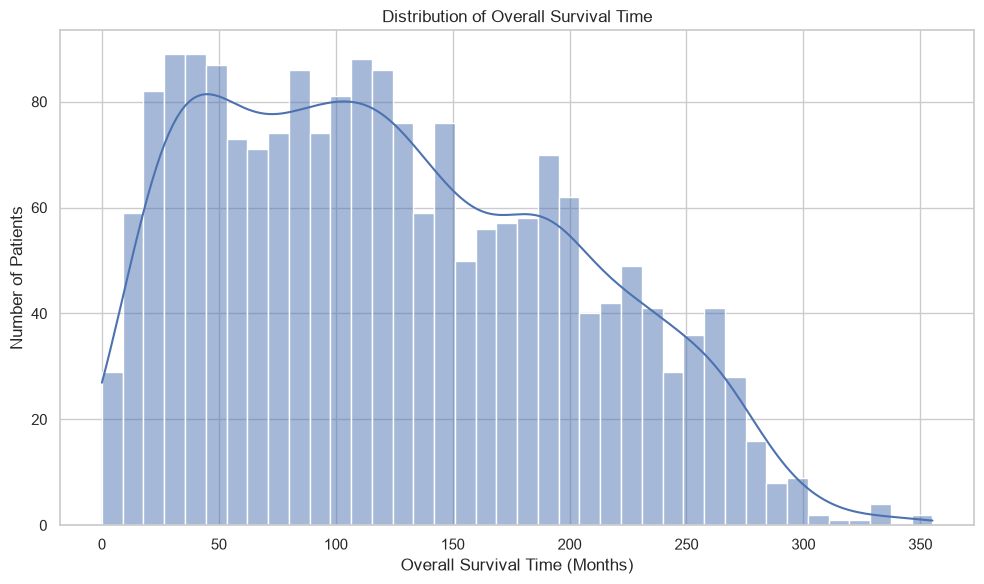

In [34]:

plt.figure(figsize=(10, 6))

sns.histplot(
    data=survival_df,
    x="OS_MONTHS",
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Overall Survival Time"
)

plt.xlabel(
    "Overall Survival Time (Months)"
)

plt.ylabel(
    "Number of Patients"
)

plt.tight_layout()

plt.show()

Age at diagnosis summary:


count    1981.000000
mean       61.086986
std        12.949710
min        21.930000
25%        51.420000
50%        61.810000
75%        70.600000
max        96.290000
Name: AGE_AT_DIAGNOSIS, dtype: float64

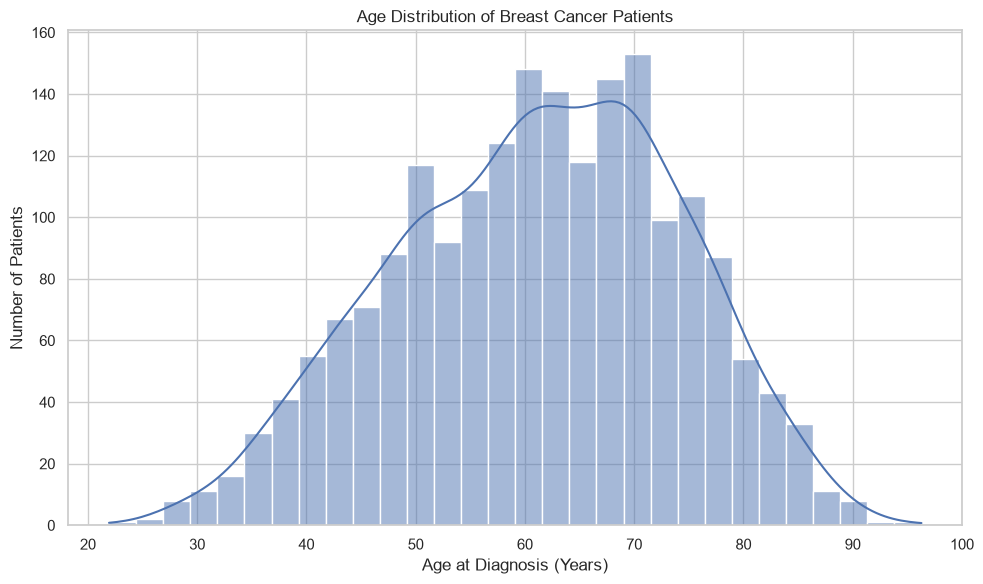

In [36]:

print("Age at diagnosis summary:")

display(
    survival_df["AGE_AT_DIAGNOSIS"].describe()
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=survival_df,
    x="AGE_AT_DIAGNOSIS",
    bins=30,
    kde=True
)

plt.title(
    "Age Distribution of Breast Cancer Patients"
)

plt.xlabel("Age at Diagnosis (Years)")

plt.ylabel("Number of Patients")

plt.tight_layout()

plt.show()

In [38]:

clinical_variables = [
    "TUMOR_STAGE",
    "GRADE",
    "ER_STATUS",
    "HER2_STATUS",
    "PR_STATUS",
    "CHEMOTHERAPY",
    "HORMONE_THERAPY",
    "RADIO_THERAPY"
]

for col in clinical_variables:

    print("\n" + "=" * 50)

    print("Variable:", col)

    print("=" * 50)

    print(
        survival_df[col].value_counts(
            dropna=False
        )
    )


Variable: TUMOR_STAGE
TUMOR_STAGE
2.0    825
NaN    515
1.0    501
3.0    118
0.0     12
4.0     10
Name: count, dtype: int64

Variable: GRADE
GRADE
3.0    953
2.0    771
1.0    169
NaN     88
Name: count, dtype: int64

Variable: ER_STATUS
ER_STATUS
Positive    1507
Negative     474
Name: count, dtype: int64

Variable: HER2_STATUS
HER2_STATUS
Negative    1733
Positive     247
NaN            1
Name: count, dtype: int64

Variable: PR_STATUS
PR_STATUS
Positive    1040
Negative     940
NaN            1
Name: count, dtype: int64

Variable: CHEMOTHERAPY
CHEMOTHERAPY
NO     1568
YES     412
NaN       1
Name: count, dtype: int64

Variable: HORMONE_THERAPY
HORMONE_THERAPY
YES    1216
NO      764
NaN       1
Name: count, dtype: int64

Variable: RADIO_THERAPY
RADIO_THERAPY
YES    1173
NO      807
NaN       1
Name: count, dtype: int64


In [40]:

missing_summary = pd.DataFrame({
    "Missing_Count": survival_df.isna().sum(),
    "Missing_Percentage": (
        survival_df.isna().mean() * 100
    )
})

missing_summary = missing_summary.sort_values(
    by="Missing_Percentage",
    ascending=False
)

display(missing_summary)

,Missing_Count,Missing_Percentage
TUMOR_STAGE,515,25.996971
THREEGENE,217,10.954064
LATERALITY,111,5.603231
GRADE,88,4.442201
LYMPH_NODES_EXAMINED_POSITIVE,76,3.836446
CELLULARITY,64,3.230692
HISTOLOGICAL_SUBTYPE,44,2.221100
ER_IHC,43,2.170621
BREAST_SURGERY,26,1.312468
TUMOR_SIZE,26,1.312468


In [42]:


processed_dir = PROJECT_DIR / "processed_data"

processed_dir.mkdir(
    parents=True,
    exist_ok=True
)


output_file = (
    processed_dir /
    "metabric_survival_cohort.csv"
)

survival_df.to_csv(
    output_file,
    index=False
)

print(
    "Dataset saved successfully!"
)

print(
    "File location:",
    output_file
)

print(
    "Final dataset shape:",
    survival_df.shape
)

Dataset saved successfully!
File location: /Users/monicachaganti/Desktop/Ph.D/PROJECTS/brca_metabric/processed_data/metabric_survival_cohort.csv
Final dataset shape: (1981, 37)
